In [6]:
from textblob import TextBlob
import pandas as pd
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')
news_df['date'] = pd.to_datetime(news_df['date'], utc=True, format='mixed')

print("Data loaded:", news_df.shape)

Data loaded: (1407328, 6)


In [3]:
news_df["sentiment"] = news_df["headline"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

In [4]:
news_df["date"] = pd.to_datetime(news_df["date"]).dt.date

daily_sentiment = news_df.groupby("date")["sentiment"].mean()

In [8]:
import pandas as pd


import os
print(os.listdir('../data/raw/'))  

['AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'META.csv', 'NVDA.csv', 'raw_analyst_ratings.csv']


In [9]:

stock_df = pd.read_csv('../data/raw/AAPL.csv')  
stock_df["Daily_Return"] = stock_df["Close"].pct_change()

print(stock_df.shape)
print(stock_df.columns.tolist())
print(stock_df.head())

(3774, 7)
['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return']
         Date     Close      High       Low      Open      Volume  \
0  2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200   
1  2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400   
2  2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400   
3  2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800   
4  2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800   

   Daily_Return  
0           NaN  
1      0.042204  
2     -0.016494  
3     -0.021609  
4      0.018570  


In [10]:
# Convert date columns to same type so merge works
stock_df["Date"] = pd.to_datetime(stock_df["Date"]).dt.date

merged = pd.merge(
    daily_sentiment.reset_index(),
    stock_df[["Date", "Close", "Daily_Return"]],
    left_on="date",
    right_on="Date",
    how="inner"
).drop(columns=["Date"])

print("Merged shape:", merged.shape)
print(merged.head())

Merged shape: (2757, 4)
         date  sentiment     Close  Daily_Return
0  2009-04-27   0.000000  3.740782      0.006699
1  2009-04-29   0.000000  3.753081      0.010008
2  2009-05-22   0.000000  3.673902     -0.013529
3  2009-05-27   0.234091  3.990310      0.017358
4  2009-05-29   0.068182  4.073082      0.005479


In [12]:
from scipy.stats import pearsonr

corr, pvalue = pearsonr(merged["sentiment"], merged["Daily_Return"].fillna(0))

print(f"Pearson Correlation: {corr:.4f}")
print(f"P-value:             {pvalue:.4f}")

if pvalue < 0.05:
    print("Statistically significant (p < 0.05)")
else:
    print("Not statistically significant (p >= 0.05)")

Pearson Correlation: 0.0439
P-value:             0.0210
Statistically significant (p < 0.05)


In [13]:
# News might affect stock prices the NEXT day, not the same day
# So we test lags: sentiment today vs return tomorrow, day after, etc.

lag_correlations = {}

for lag in range(0, 6):  # lag 0 = same day, lag 1 = next day, etc.
    shifted_return = merged["Daily_Return"].shift(-lag)
    valid = merged["sentiment"].notna() & shifted_return.notna()
    corr, pval = pearsonr(merged["sentiment"][valid], shifted_return[valid])
    lag_correlations[lag] = {"correlation": corr, "p_value": pval}

lag_df = pd.DataFrame(lag_correlations).T
lag_df.index.name = "Lag (days)"
print(lag_df.round(4))

            correlation  p_value
Lag (days)                      
0                0.0439   0.0210
1                0.0012   0.9477
2               -0.0070   0.7126
3                0.0131   0.4923
4                0.0166   0.3852
5               -0.0018   0.9250


In [14]:
merged["EMA_12"] = merged["Close"].ewm(span=12, adjust=False).mean()
merged["EMA_26"] = merged["Close"].ewm(span=26, adjust=False).mean()


In [15]:
merged["MACD"] = merged["EMA_12"] - merged["EMA_26"]
merged["Signal_Line"] = merged["MACD"].ewm(span=9, adjust=False).mean()
merged["MACD_Histogram"] = merged["MACD"] - merged["Signal_Line"]


In [16]:
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

merged["RSI"] = compute_rsi(merged["Close"])

print("Technical indicators added ")
print(merged[["date", "Close", "EMA_12", "EMA_26", "MACD", "RSI"]].tail(10))

Technical indicators added 
            date      Close     EMA_12     EMA_26      MACD        RSI
2747  2020-05-29  77.102577  76.183921  73.870575  2.313346  59.878582
2748  2020-06-01  78.050789  76.471131  74.180221  2.290911  58.869310
2749  2020-06-02  78.412117  76.769745  74.493694  2.276050  66.364892
2750  2020-06-03  78.843788  77.088828  74.815924  2.272905  75.341098
2751  2020-06-04  78.164757  77.254356  75.063985  2.190370  68.061143
2752  2020-06-05  80.390961  77.736910  75.458576  2.278334  77.837603
2753  2020-06-08  80.866280  78.218352  75.859147  2.359205  74.706212
2754  2020-06-09  83.419868  79.018585  76.419200  2.599385  83.423568
2755  2020-06-10  85.566071  80.025891  77.096746  2.929144  84.359002
2756  2020-06-11  81.457993  80.246214  77.419801  2.826412  65.007061


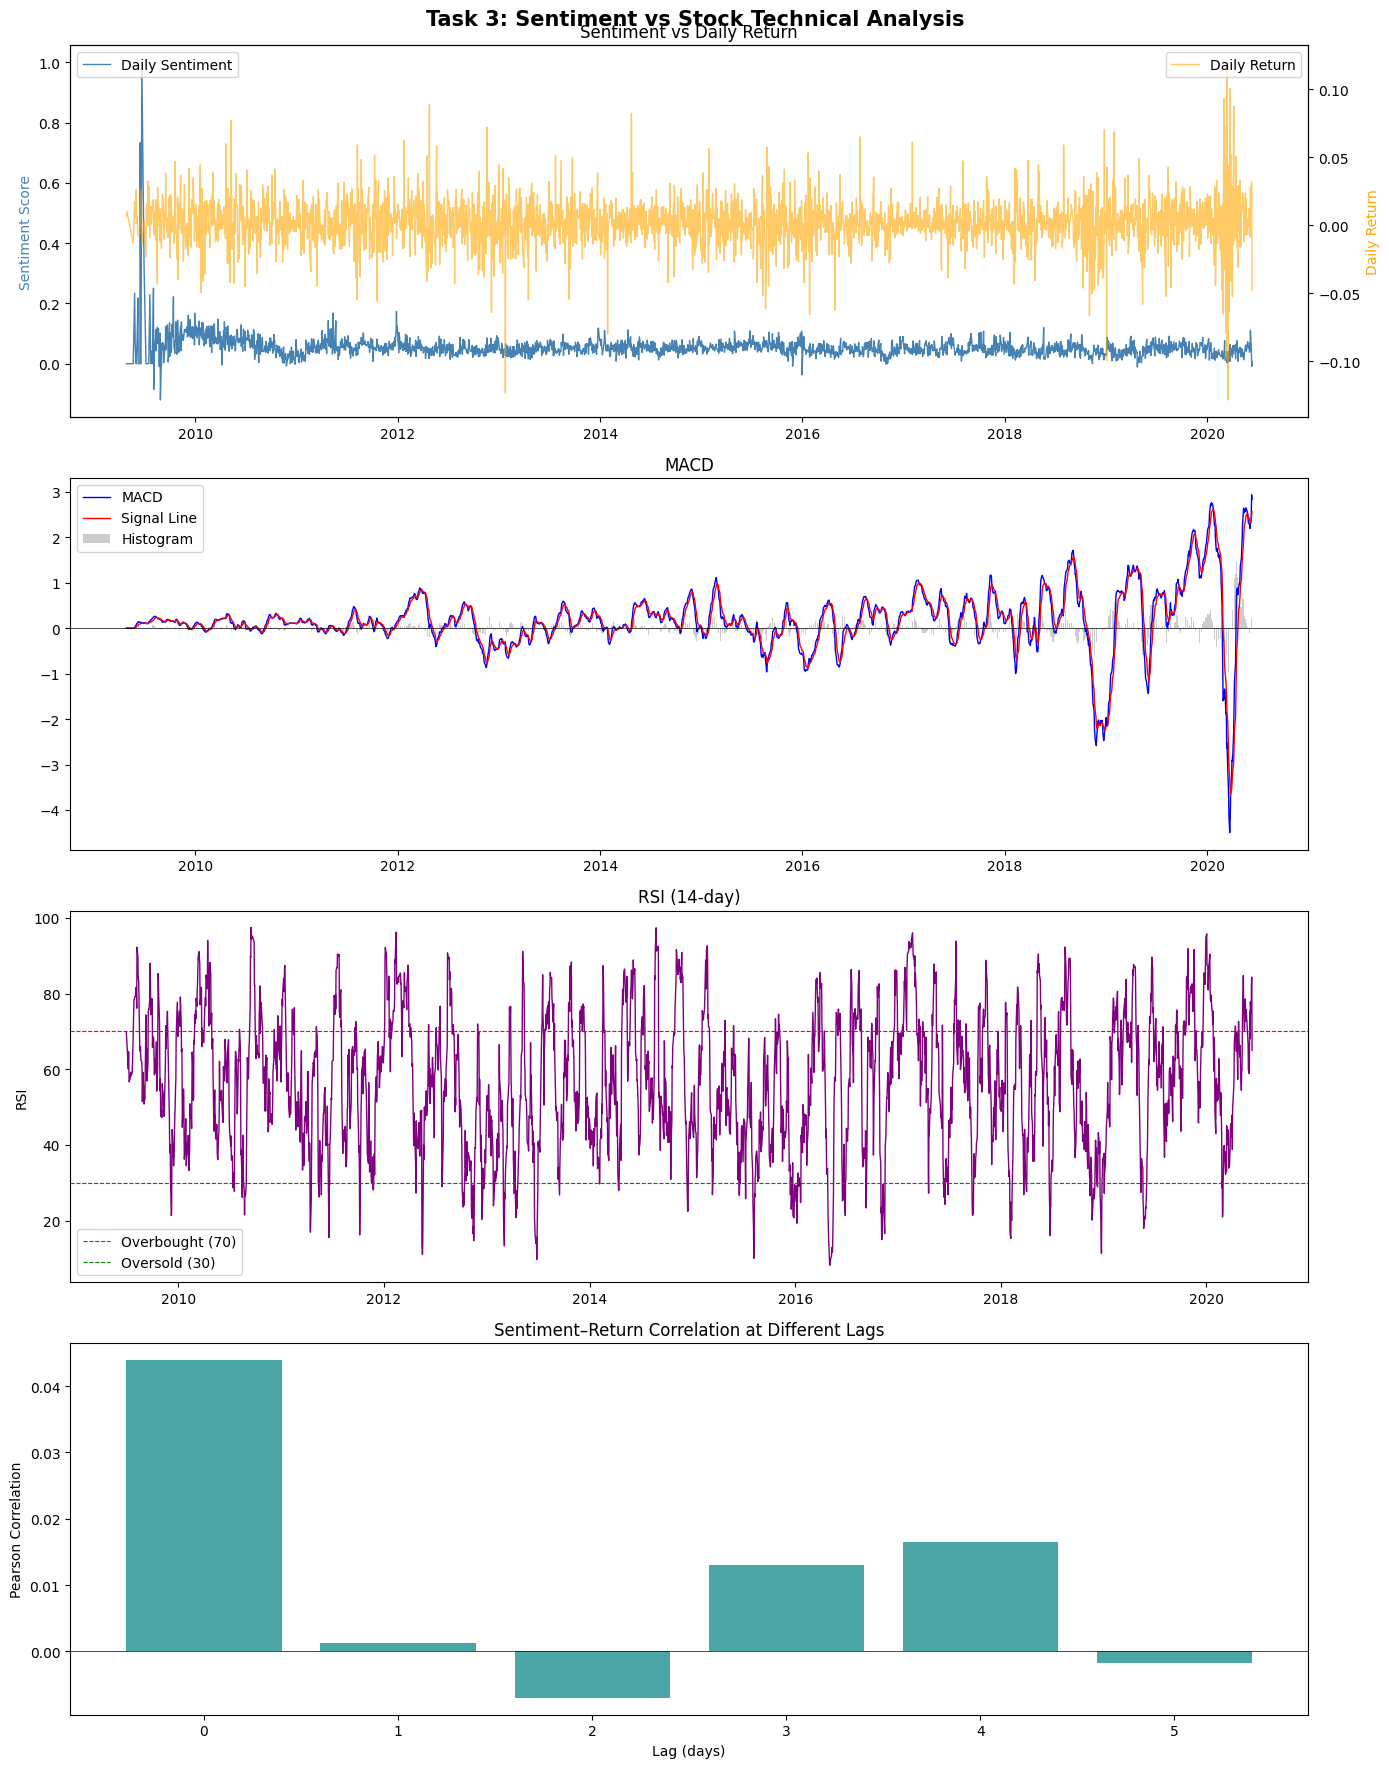

Plot saved


<Figure size 640x480 with 0 Axes>

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(14, 18))
fig.suptitle("Task 3: Sentiment vs Stock Technical Analysis", fontsize=15, fontweight='bold')

dates = pd.to_datetime(merged["date"])

# Plot 1: Sentiment vs Daily Return
ax1 = axes[0]
ax1.plot(dates, merged["sentiment"], color="steelblue", label="Daily Sentiment", linewidth=1)
ax1_twin = ax1.twinx()
ax1_twin.plot(dates, merged["Daily_Return"], color="orange", alpha=0.6, label="Daily Return", linewidth=1)
ax1.set_ylabel("Sentiment Score", color="steelblue")
ax1_twin.set_ylabel("Daily Return", color="orange")
ax1.set_title("Sentiment vs Daily Return")
ax1.legend(loc="upper left"); ax1_twin.legend(loc="upper right")

# Plot 2: MACD
ax2 = axes[1]
ax2.plot(dates, merged["MACD"], label="MACD", color="blue", linewidth=1)
ax2.plot(dates, merged["Signal_Line"], label="Signal Line", color="red", linewidth=1)
ax2.bar(dates, merged["MACD_Histogram"], label="Histogram", color="gray", alpha=0.4, width=1)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_title("MACD")
ax2.legend()

# Plot 3: RSI
ax3 = axes[2]
ax3.plot(dates, merged["RSI"], color="purple", linewidth=1)
ax3.axhline(70, color="red", linestyle="--", linewidth=0.8, label="Overbought (70)")
ax3.axhline(30, color="green", linestyle="--", linewidth=0.8, label="Oversold (30)")
ax3.set_title("RSI (14-day)")
ax3.set_ylabel("RSI")
ax3.legend()

# Plot 4: Lag Correlation
ax4 = axes[3]
ax4.bar(lag_df.index, lag_df["correlation"], color="teal", alpha=0.7)
ax4.axhline(0, color="black", linewidth=0.5)
ax4.set_xlabel("Lag (days)")
ax4.set_ylabel("Pearson Correlation")
ax4.set_title("Sentiment–Return Correlation at Different Lags")
ax4.set_xticks(range(6))

plt.tight_layout()
import os
os.makedirs("../reports", exist_ok=True)  # creates the folder if it doesn't exist

plt.tight_layout()
plt.savefig("../reports/task3_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved")
plt.savefig("../reports/task3_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
